In [1]:
from final.part_3__Pong_v5_modules.ActorCritic import A2CActorCritic
import ale_py

In [2]:
reward_history_env1  = []    
entropy_history_env1 = []     
step_index_env1      = []  

reward_history_env2  = []    
entropy_history_env2 = []     
step_index_env2      = []  

def plot_reward_entropy(rewards, entropies, steps, title="Return vs Entropy"):
    import matplotlib.pyplot as plt
    import numpy as np

    steps = np.asarray(steps)
    fig, ax1 = plt.subplots()

    ax1.set_xlabel("Update")
    ax1.set_ylabel("Average return", color="tab:blue")
    ax1.plot(steps, rewards, color="tab:blue", label="Average return")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Entropy", color="tab:red")
    ax2.plot(steps, entropies, color="tab:red", label="Entropy")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()


In [3]:
import logging,csv,os
logging.basicConfig(level=logging.INFO,format='%(asctime)s %(levelname)s %(message)s',datefmt='%H:%M:%S')

In [17]:
import time, os, logging, multiprocessing as mp
from typing import Tuple

import gymnasium as gym
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim

from final.part_3__BipedalWalker_V3_modules.compute_returns import calculate_returns
from final.part_3__BipedalWalker_V3_modules.worker          import worker_loop
from final.part_3__BipedalWalker_V3_modules.ActorCritic     import A2CActorCritic


logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
handler = logging.StreamHandler()
handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s: %(message)s"))
logger.addHandler(handler)


lr_actor=0.0001
lr_critic=0.0001
gamma=0.99
rollout_steps=4
num_workers=4
max_updates=40000000
initial_ent_coef= 1
final_ent_coef=0.005
initial_temp=1.5
final_temp=1.0
value_loss_coef=0.5
freeze_critic_iters=0
max_grad_norm=5
save_interval=10000
log_interval=10000
seed=1

def get_ent_coef(step: int) -> float:
    if step <= 1_000:
        return 1.0 - (1.0 - 0.999) * (step / 1_000)

    elif step <= 10_000_000:
        x0, x1 = 1_000, 10_000_000
        y0, y1 = np.log(0.999), np.log(0.333)
        y = y0 + (y1 - y0) * ((step - x0) / (x1 - x0))
        return float(np.exp(y))

    elif step <= 15_000_000:
        x0, x1 = 10_000_000, 20_000_000
        y0, y1 = np.log(0.333), np.log(0.02)
        y = y0 + (y1 - y0) * ((step - x0) / (x1 - x0))
        return float(np.exp(y))

    else:
        return 0.005

device = torch.device("cpu")

def make_optimizers(model):
    policy_params, critic_params = [], []
    for n, p in model.named_parameters():
        if "value_head" in n:
            critic_params.append(p)
        else:
            policy_params.append(p)
            if "policy_head" not in n and "log_std" not in n:
                critic_params.append(p)
    return (
        optim.Adam(policy_params, lr=lr_actor,  eps=1e-5),
        optim.Adam(critic_params,  lr=lr_critic, eps=1e-5),
    )


import os, time, logging, multiprocessing as mp
import numpy as np, torch


checkpoint_path = "a3_part_3_a2c_ENV2_ssaurav_asinha25.pth"   # centralised name

if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)
    torch.manual_seed(seed);  np.random.seed(seed)

    model = A2CActorCritic().to(device)
    model.share_memory()
    actor_opt, critic_opt = make_optimizers(model)

    start_update = 1
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        if isinstance(ckpt, dict) and "model" in ckpt:         
            model.load_state_dict(ckpt["model"])
            actor_opt.load_state_dict(ckpt["actor_opt"])
            critic_opt.load_state_dict(ckpt["critic_opt"])
            start_update = ckpt.get("update", 1) + 1
            logger.info(f"Resuming from update {start_update-1}")
        else:                                                  
            model.load_state_dict(ckpt)
            logger.info("Loaded existing weights – optimisers reset")

  
    exp_q = mp.Queue()
    for pid in range(num_workers):
        p = mp.Process(target=worker_loop,
                       args=(pid, exp_q, model, rollout_steps))
        p.daemon = True
        p.start()
    logger.info(f"Spawned {num_workers} workers")

    
    t0 = time.time()
    for update in range(start_update, max_updates + 1):        
        S_buf, A_buf, R_buf = [], [], []
        for _ in range(num_workers):
            s, a, r, d, last_v = exp_q.get()
            with torch.no_grad():
                G = calculate_returns(r, d, last_v, model, gamma)
            S_buf.extend(s);  A_buf.extend(a);  R_buf.extend(G)

      
        s_batch = torch.as_tensor(np.vstack(S_buf), dtype=torch.float32, device=device)
        a_batch = torch.as_tensor(np.vstack(A_buf), dtype=torch.float32, device=device)
        r_batch = torch.as_tensor(R_buf,         dtype=torch.float32, device=device)

       
        ratio     = update / max_updates
        temp      = initial_temp   - (initial_temp   - final_temp)   * ratio
        ent_coef  = initial_ent_coef - (initial_ent_coef - final_ent_coef) * ratio
        ent_coef  = max(get_ent_coef(update), 0.005)   

       
        dist, values = model(s_batch, temp=temp)
        logp = dist.log_prob(a_batch).sum(-1)
        logp = logp.clamp(-20, 20) 
        ent  = dist.entropy().sum(-1).mean()

       
        raw_adv   = r_batch - values.detach()
        adv_norm  = (raw_adv - raw_adv.mean())   / (raw_adv.std() + 1e-8)
        adv_norm  = adv_norm.clamp(-10, 10)

        actor_loss  = -(logp * adv_norm).mean()
        critic_loss = value_loss_coef * F.mse_loss(values, r_batch)
        entropy_pen = -ent_coef * ent
        total_loss  = actor_loss + critic_loss + entropy_pen

      
        actor_opt.zero_grad();  critic_opt.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        actor_opt.step();  critic_opt.step()

       
        if update % log_interval == 0:
            fps = (update * num_workers * rollout_steps) / (time.time() - t0)
            avg_return = float(r_batch.mean())
            reward_history_env2.append(avg_return)
            entropy_history_env2.append(ent.item())
            step_index_env2.append(update)
            logger.info(
                f"Up {update:>6}/{max_updates:<6} | "
                f"Return {avg_return:8.1f} | "
                f"Actor-L {actor_loss.item():7.9f} | "
                f"Critic-L {critic_loss.item():7.3f} | "
                f"Entropy {ent.item():6.3f} | "
                f"η {ent_coef:7.4f} | "
                f"FPS {fps:6.1f}"
            )

      
        if update % save_interval == 0:
            torch.save(
                {
                    "model":      model.state_dict(),
                    "actor_opt":  actor_opt.state_dict(),
                    "critic_opt": critic_opt.state_dict(),
                    "update":     update,
                },
                checkpoint_path,
            )

A2CActorCritic: obs=24, actions=4, params=74.0k
01:41:01 INFO A2CActorCritic: obs=24, actions=4, params=74.0k
2025-04-27 01:41:01,716 INFO: Resuming from update 30130000
2025-04-27 01:41:01,716 INFO: Resuming from update 30130000
01:41:01 INFO Resuming from update 30130000
2025-04-27 01:41:01,739 INFO: Spawned 4 workers
2025-04-27 01:41:01,739 INFO: Spawned 4 workers
01:41:01 INFO Spawned 4 workers
2025-04-27 01:41:40,659 INFO: Up 30140000/40000000 | Return    -46.0 | Actor-L -0.013113022 | Critic-L   1.118 | Entropy  7.676 | η  0.0050 | FPS 12391726.9
2025-04-27 01:41:40,659 INFO: Up 30140000/40000000 | Return    -46.0 | Actor-L -0.013113022 | Critic-L   1.118 | Entropy  7.676 | η  0.0050 | FPS 12391726.9
01:41:40 INFO Up 30140000/40000000 | Return    -46.0 | Actor-L -0.013113022 | Critic-L   1.118 | Entropy  7.676 | η  0.0050 | FPS 12391726.9
2025-04-27 01:42:43,669 INFO: Up 30150000/40000000 | Return    -60.3 | Actor-L -1.152483344 | Critic-L   0.499 | Entropy  7.676 | η  0.0050 | F

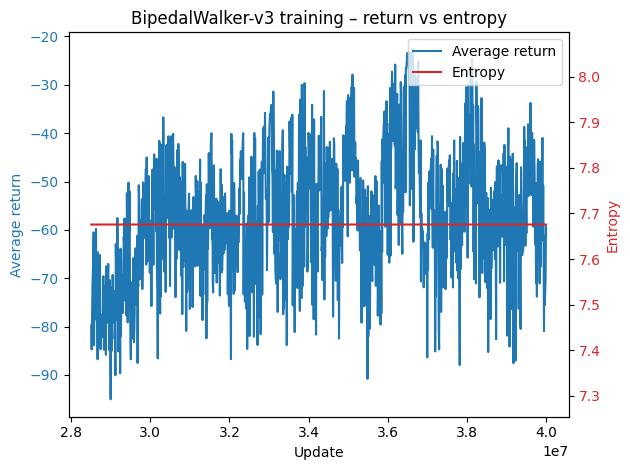

In [18]:
plot_reward_entropy(reward_history_env2,
                    entropy_history_env2,
                    step_index_env2,
                    title="BipedalWalker-v3 training – return vs entropy")

In [3]:

from typing import Tuple
from final.part_3__BipedalWalker_V3_modules.ActorCritic import A2CActorCritic
import os, torch, numpy as np, matplotlib.pyplot as plt, gymnasium as gym

device = torch.device("cpu")

def evaluate_policy(
    model: torch.nn.Module = None,
    eval_episodes: int = 10,
    human_mode: bool = False,
    show_plot     = True,
) -> Tuple[float, float]:
    model_path = "a3_part_3_a2c_ENV2_ssaurav_asinha25.pth"

    if model is None:
        model = A2CActorCritic().to(device)

    if os.path.exists(model_path):
        state = torch.load(model_path, map_location=device)
        if isinstance(state, dict) and "model" in state:
            model.load_state_dict(state["model"])
        else:
            model.load_state_dict(state)
        print(f"Loaded weights from {model_path}")
    else:
        print("No checkpoint found. Using untrained model.")

    model.eval()

    env = gym.make("BipedalWalker-v3", render_mode="human" if human_mode else None)

    returns = []
    for ep in range(eval_episodes):
        obs, _ = env.reset()
        done = False
        total = 0.0
        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_tensor)
                action = dist.sample()[0].clamp(-1.0, 1.0).cpu().numpy()
            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            total += reward
        returns.append(total)
        print(f"Episode {ep+1}/{eval_episodes}: Return = {total:.2f}")

    avg, std = float(np.mean(returns)), float(np.std(returns))
    print(f"\n Eval Result → Average Return: {avg:.2f} ± {std:.2f}")

    if show_plot:
        plt.figure(figsize=(6,3))
        plt.plot(returns, marker='o')
        plt.axhline(avg, ls='--')
        plt.title(f"Evaluation at update {40000000}\nμ={avg:.1f}  σ={std:.1f}")
        plt.xlabel("Episode")
        plt.ylabel("Return")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    return avg, std


A2CActorCritic: obs=24, actions=4, params=74.0k


Loaded weights from a3_part_3_a2c_ENV2_ssaurav_asinha25.pth
Episode 1/10: Return = -130.60
Episode 2/10: Return = -96.29
Episode 3/10: Return = -123.77
Episode 4/10: Return = -135.06
Episode 5/10: Return = -122.17
Episode 6/10: Return = -130.73
Episode 7/10: Return = -127.75
Episode 8/10: Return = -130.88
Episode 9/10: Return = -125.56
Episode 10/10: Return = -108.56

 Eval Result → Average Return: -123.14 ± 11.30


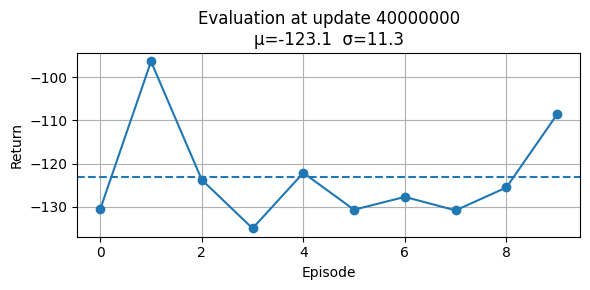

(-123.13980865478516, 11.301647186279297)

In [4]:
evaluate_policy( human_mode=True)